<a href="https://colab.research.google.com/github/lenmecc/miniature-enigma/blob/main/espesores_por_maquinaLaser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Actividad 1.1.1. Mapear capacidades de las cortadoras laser**

* Objetivo: Identificar patrones en el acomodo por espesor en las diferentes maquinas de corte laser

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np

Primero analizamos los planes de corte laser hechos por el experto en los periodos de octubre-noviembre del 2025.

In [ ]:
!unzip "/content/drive/MyDrive/Master/Master - Aplicado a EZI/PIC/Random/Programación 3 semanas"

Archive:  /content/drive/MyDrive/Master/Master - Aplicado a EZI/PIC/Random/Programación 3 semanas.zip
   creating: Programación 3 semanas/
  inflating: Programación 3 semanas/Plan de Corte 031125.xlsx  
  inflating: Programación 3 semanas/Plan de Corte 041125.xlsx  
  inflating: Programación 3 semanas/Plan de Corte 05.11.25.xlsx  
  inflating: Programación 3 semanas/Plan de Corte 06.11.25.xlsx  
  inflating: Programación 3 semanas/Plan de Corte 07.11.25.xlsx  
  inflating: Programación 3 semanas/Plan de Corte 081125.xlsx  
  inflating: Programación 3 semanas/Plan de Corte 10.11.25.xlsx  
  inflating: Programación 3 semanas/Plan de Corte 111125.xlsx  
  inflating: Programación 3 semanas/Plan de Corte 191025.xlsx  
  inflating: Programación 3 semanas/Plan de Corte 20.10.25.xlsx  
  inflating: Programación 3 semanas/Plan de Corte 201025.xlsx  
  inflating: Programación 3 semanas/Plan de Corte 211025.xlsx  
  inflating: Programación 3 semanas/Plan de Corte 22.10.25.xlsx  
  inflating: Prog

In [ ]:
espesor = pd.read_excel("espesores_P1.xlsx")

In [ ]:
import glob
import pandas as pd

# Get a list of all Excel files in the specified directory
excel_files = glob.glob('Programación 3 semanas/*.xlsx')

# Create an empty list to store individual DataFrames
df_list = []

# Loop through each file, read it into a DataFrame, and append to the list
for file in excel_files:
    df_temp = pd.read_excel(file)
    df_list.append(df_temp)

# Concatenate all DataFrames in the list into a single DataFrame
df_combined = pd.concat(df_list, ignore_index=True)

# Display the first 5 rows of the combined DataFrame and its information
display(df_combined.head())
df_combined.info()

,No,Maquina,Folio,Programa,Bloque,Material,Cantidad,Material.1,En,Horas,Unnamed: 10,Unnamed: 11,Unnamed: 12,Horas.1,Cerrar,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,NaN,NaN,NaN,NaN,NaN,NaN,Placas,Surtido,Proceso,Corte,Setup,Inicio Corte,Fin Corte,Acum,Nesteo,Fecha,Disponible,terminadas
1,1.0,LASER 01,356607.0,huesonavistaramada-02,70,ACPL0950G50NT48120,12,,,12.4,Oct 19 2025 11:25AM,Oct 19 2025 11:40AM,Oct 20 2025 12:04AM,13,,2025-10-17 18:56:04.160000,1,0
2,2.0,LASER 01,356641.0,P1 GALLETADEMA,61,ACPL0635SA36D48120,11,,,6.42,Oct 20 2025 7:53AM,Oct 20 2025 8:08AM,Oct 20 2025 2:33PM,27,,2025-10-18 15:36:50.783000,26,0
3,3.0,LASER 01,355638.0,9001-6,70,ACPL0600G80NT48108,17,,,4.52,Oct 20 2025 12:04AM,Oct 20 2025 12:19AM,Oct 20 2025 4:50AM,17,,2025-10-04 14:37:24.150000,NaN,0
4,4.0,LASER 01,356624.0,pisocnhajuste-6,10,ACLM10-1008DC48120,28,,,2.8,Oct 20 2025 4:50AM,Oct 20 2025 5:05AM,Oct 20 2025 7:53AM,20,,2025-10-18 12:50:34.677000,-26,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   No           985 non-null    float64
 1   Maquina      985 non-null    object 
 2   Folio        985 non-null    float64
 3   Programa     985 non-null    object 
 4   Bloque       909 non-null    object 
 5   Material     985 non-null    object 
 6   Cantidad     1005 non-null   object 
 7   Material.1   1005 non-null   object 
 8   En           1005 non-null   object 
 9   Horas        1005 non-null   object 
 10  Unnamed: 10  1005 non-null   object 
 11  Unnamed: 11  1005 non-null   object 
 12  Unnamed: 12  1005 non-null   object 
 13  Horas.1      1005 non-null   object 
 14  Cerrar       1005 non-null   object 
 15  Unnamed: 15  1005 non-null   object 
 16  Unnamed: 16  857 non-null    object 
 17  Unnamed: 17  1005 non-null   object 
dtypes: float64(2), object(16)
memory usage: 141.5+ K

In [ ]:
df_combined.duplicated().sum()

np.int64(19)

In [ ]:
df_combined.drop_duplicates(inplace=True)

In [ ]:
df_combined.drop(columns=['No',"Folio","Programa","Bloque","Cantidad","Material.1","En","Horas","Unnamed: 10","Unnamed: 11","Unnamed: 12",
                          "Horas.1","Cerrar","Unnamed: 15","Unnamed: 16","Unnamed: 17"], inplace=True)

In [ ]:
df_combined.head()

,Maquina,Material
0,NaN,NaN
1,LASER 01,ACPL0950G50NT48120
2,LASER 01,ACPL0635SA36D48120
3,LASER 01,ACPL0600G80NT48108
4,LASER 01,ACLM10-1008DC48120


In [ ]:
df_combined.drop(0, inplace=True)

In [ ]:
df_combined.head()

,Maquina,Material
1,LASER 01,ACPL0950G50NT48120
2,LASER 01,ACPL0635SA36D48120
3,LASER 01,ACPL0600G80NT48108
4,LASER 01,ACLM10-1008DC48120
5,LASER 03,ACPL1200G50NT48150


In [ ]:
espesor = espesor.rename(columns={'Placa': 'Material'})
df_final = df_combined.merge(espesor, on='Material', how='left')

In [ ]:
display(df_final.head())
df_final.info()

,Maquina,Material,Espesor,Ancho MM,Largo MM
0,LASER 01,ACPL1600G50NT60096-CH,16.00,1524.00,2438.00
1,LASER 01,ACPL1600G50NT60096-CH,16.00,1524.00,2438.00
2,LASER 01,ACPL1400G50NT66102,14.00,1676,2591
3,LASER 01,ACPL1400G50NT66102,14.00,1676,2591
4,LASER 01,ACPL0635SA36D48120,6.35,1219.00,3048.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Maquina   985 non-null    object 
 1   Material  985 non-null    object 
 2   Espesor   928 non-null    float64
 3   Ancho MM  928 non-null    object 
 4   Largo MM  928 non-null    object 
dtypes: float64(1), object(4)
memory usage: 38.6+ KB


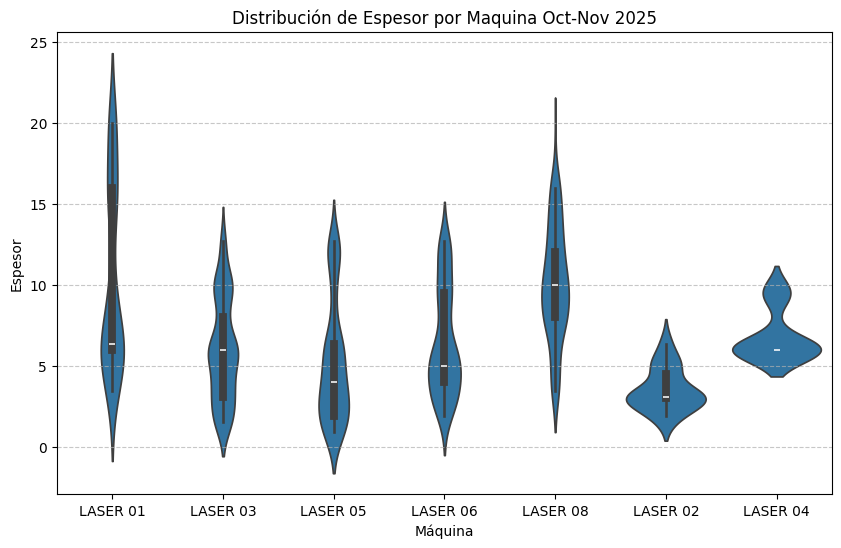

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

variable = 'Espesor'
plt.figure(figsize=(10, 6))
sns.violinplot(x='Maquina', y=variable, data=df_final)
plt.title(f'Distribución de {variable} por Maquina Oct-Nov 2025')
plt.xlabel('Máquina')
plt.ylabel(variable)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import plotly.express as px

fig = px.violin(df_final, x='Maquina', y='Espesor',
                title='Distribución de Espesor por Máquina Oct-Nov 2025',
                labels={'Maquina': 'Máquina', 'Espesor': 'Espesor'})
fig.update_layout(xaxis_title='Máquina', yaxis_title='Espesor', height=600, width=1200)
fig.show()

**Observaciones:**

* Laser 1: Espesores desde 0 hasta 22, mayor concentracion en rango ?? hacer histograma

* Laser 3: 0 hasta 15, mayor concentracion en rango 0 a 5.5

* Laser 5: 0 hasta 15, mayor concentracion en rango 0 a 5

* Laser 6: 0 hasta 15, mayor concetracion en rango 0 a 5.5.

* Laser 8: 1 hasta 20, mayor concentracion en rango 5.5 a 13.

* Laser 4: Se utiliza para 1 solo para Sisamex, espesor desde 5 hasta 6, lo cual explica la poca variedad de espesores.

* Laser 2: 0 hasta 6.6, mayor concetracion en rango 0 a 5.


Ahora, hacemos el mismo grafico para los planes de corte generados de enero del 2026 a la fecha.

In [ ]:
!unzip "/content/drive/MyDrive/Master/Master - Aplicado a EZI/PIC/Random/Plan de Corte 2026"

Archive:  /content/drive/MyDrive/Master/Master - Aplicado a EZI/PIC/Random/Plan de Corte 2026.zip
  inflating: Plan de Corte 270426.xlsx  
  inflating: Plan de Corte 260426.xlsx  
  inflating: Plan de Corte 250426.xlsx  
  inflating: Plan de Corte 240426.xlsx  
  inflating: Plan de Corte 230426.xlsx  
  inflating: Plan de Corte 220426.xlsx  
  inflating: Plan de Corte 210426.xlsx  
  inflating: Plan de Corte 2004262.xlsx  
  inflating: Plan de Corte 190426.xlsx  
  inflating: Plan de Corte 180426.xlsx  
  inflating: Plan de Corte 170426.xlsx  
  inflating: Plan de Corte 160426.xlsx  
  inflating: Plan de Corte 150426.xlsx  
  inflating: Plan de Corte 130426.xlsx  
  inflating: Plan de Corte 090426.xlsx  
  inflating: Plan de Corte 080426.xlsx  
  inflating: Plan de Corte 070426.xlsx  
  inflating: Plan de Corte 060426L.xlsx  
  inflating: Plan de Corte 030426.xlsx  
  inflating: Plan de Corte 020426.xlsx  
  inflating: Plan de Corte 010426.xlsx  
  inflating: Plan de Corte 310326.xlsx 

In [ ]:
import glob
import pandas as pd

# Get a list of all Excel files in the specified directory
# The unzip command extracted files directly into /content/, not into a 'Plan de Corte 2026' folder.
# Correcting the glob pattern to find files directly in the current directory.
excel_files = glob.glob('Plan de Corte*.xlsx')

# Create an empty list to store individual DataFrames
df2_list = []

# Loop through each file, read it into a DataFrame, and append to the list
for file in excel_files:
    df_temp_2 = pd.read_excel(file)
    df2_list.append(df_temp_2) # Corrected: Appending df_temp_2 instead of df_temp

# Concatenate all DataFrames in the list into a single DataFrame
df_combined_2 = pd.concat(df2_list, ignore_index=True)

# Display the first 5 rows of the combined DataFrame and its information
display(df_combined_2.head())
df_combined_2.info()

,No,Maquina,Folio,Programa,Bloque,Material,Cantidad,Material.1,En,Horas,Unnamed: 10,Unnamed: 11,Unnamed: 12,Horas.1,Cerrar,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,NaN,NaN,NaN,NaN,NaN,NaN,Placas,Surtido,Proceso,Corte,Setup,Inicio Corte,Fin Corte,Acum,Nesteo,Fecha,Disponible,terminadas
1,1.0,LASER 01,362824.0,P1 sem6-20g50-26,0;10;44;50,ACPL2000G50NT60120-CH,7,,,18.77,Feb 7 2026 8:53AM,Feb 7 2026 9:08AM,Feb 8 2026 3:54AM,19,,2026-02-02 09:12:30.463000,2,0
2,2.0,LASER 01,362825.0,P2 sem6-20g50-26,0;10;44,ACPL2000G50NT60120-CH,2,,,4.7,Feb 8 2026 3:54AM,Feb 8 2026 4:09AM,Feb 8 2026 8:51AM,24,,2026-02-02 09:12:30.463000,0,0
3,3.0,LASER 01,362826.0,P3 sem6-20g50-26,0;10;44;50,ACPL2000G50NT60120-CH,1,,,2.67,Feb 8 2026 8:51AM,Feb 8 2026 9:06AM,Feb 8 2026 11:46AM,27,,2026-02-02 09:12:30.463000,-1,0
4,4.0,LASER 01,362805.0,P1 sem6-6a36-26-1,0;10;41;44;50;61,ACPL0600SA36D60135,25,,,11.25,Feb 7 2026 8:53AM,Feb 7 2026 9:08AM,Feb 7 2026 8:23PM,12,,2026-01-31 14:06:13.627000,216,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15511 entries, 0 to 15510
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   No           15415 non-null  float64
 1   Maquina      15415 non-null  object 
 2   Folio        15415 non-null  float64
 3   Programa     15415 non-null  object 
 4   Bloque       14700 non-null  object 
 5   Material     15415 non-null  object 
 6   Cantidad     15511 non-null  object 
 7   Material.1   15511 non-null  object 
 8   En           15511 non-null  object 
 9   Horas        15511 non-null  object 
 10  Unnamed: 10  15511 non-null  object 
 11  Unnamed: 11  15511 non-null  object 
 12  Unnamed: 12  15511 non-null  object 
 13  Horas.1      15511 non-null  object 
 14  Cerrar       15511 non-null  object 
 15  Unnamed: 15  15511 non-null  object 
 16  Unnamed: 16  13866 non-null  object 
 17  Unnamed: 17  15511 non-null  object 
dtypes: float64(2), object(16)
memory usage: 2.1+ M

In [ ]:
df_combined_2.duplicated().sum()

np.int64(95)

In [ ]:
df_combined_2.drop_duplicates(inplace=True)

In [ ]:
df_combined_2.drop(columns=['No',"Folio","Programa","Bloque","Cantidad","Material.1","En","Horas","Unnamed: 10","Unnamed: 11","Unnamed: 12",
                          "Horas.1","Cerrar","Unnamed: 15","Unnamed: 16","Unnamed: 17"], inplace=True)

In [ ]:
df_combined_2.head()

,Maquina,Material
0,NaN,NaN
1,LASER 01,ACPL2000G50NT60120-CH
2,LASER 01,ACPL2000G50NT60120-CH
3,LASER 01,ACPL2000G50NT60120-CH
4,LASER 01,ACPL0600SA36D60135


In [ ]:
df_combined_2.drop(0, inplace=True)
#

In [ ]:
df_final_2 = df_combined_2.merge(espesor, on='Material', how='left')

In [ ]:
df_final_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15415 entries, 0 to 15414
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Maquina   15415 non-null  object 
 1   Material  15415 non-null  object 
 2   Espesor   15165 non-null  float64
 3   Ancho MM  15165 non-null  object 
 4   Largo MM  15165 non-null  object 
dtypes: float64(1), object(4)
memory usage: 602.3+ KB


In [ ]:
df_final_2.dropna(inplace=True)

In [ ]:
df_final_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15165 entries, 0 to 15414
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Maquina   15165 non-null  object 
 1   Material  15165 non-null  object 
 2   Espesor   15165 non-null  float64
 3   Ancho MM  15165 non-null  object 
 4   Largo MM  15165 non-null  object 
dtypes: float64(1), object(4)
memory usage: 710.9+ KB


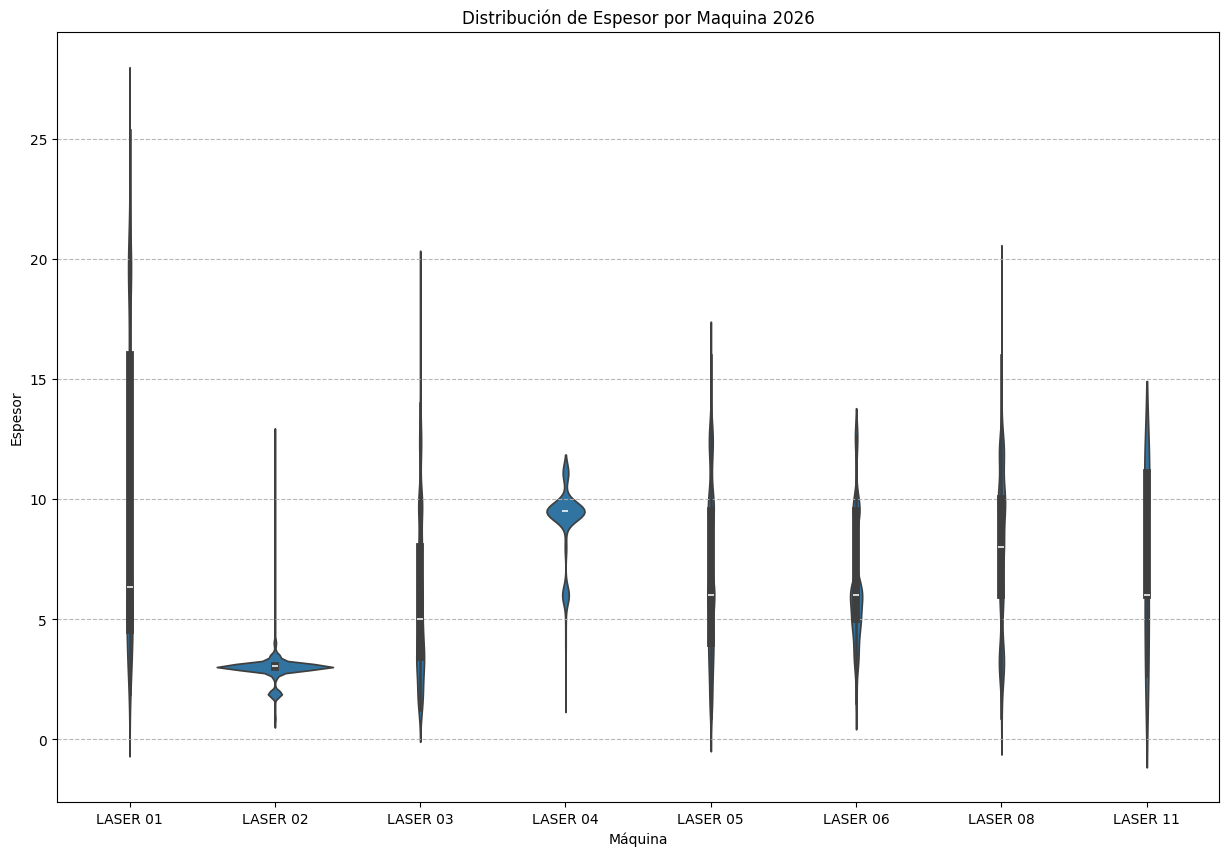

In [ ]:
variable = 'Espesor'
plt.figure(figsize=(15, 10))
sns.violinplot(x='Maquina', y=variable, data=df_final_2)
plt.title(f'Distribución de {variable} por Maquina 2026')
plt.xlabel('Máquina')
plt.ylabel(variable)
plt.grid(axis='y', linestyle='--', alpha=0.9)
plt.show()

In [ ]:
import plotly.express as px

fig = px.violin(df_final_2, x='Maquina', y='Espesor',
                title='Distribución de Espesor por Máquina 2026',
                labels={'Maquina': 'Máquina', 'Espesor': 'Espesor'})
fig.update_layout(xaxis_title='Máquina', yaxis_title='Espesor', height=600, width=1200)
fig.show()

In [ ]:
descriptive_stats = df_final_2.groupby('Maquina')['Ancho MM'].describe()
display(descriptive_stats)

,count,unique,top,freq
Maquina,,,,
LASER 01,2384,16,1524.00,754
LASER 02,1464,7,1219.00,873
LASER 03,3726,16,1219.00,1791
LASER 04,939,9,1828.8,699
LASER 05,2650,17,1219.00,1243
LASER 06,2684,12,1524.00,988
LASER 08,1296,11,1219.00,388
LASER 11,22,3,1828.8,15


In [ ]:
descriptive_stats = df_final_2.groupby('Maquina')['Largo MM'].describe()
display(descriptive_stats)

,count,unique,top,freq
Maquina,,,,
LASER 01,2384,18,3048.00,684
LASER 02,1464,6,3048.00,927
LASER 03,3726,26,3048.00,1816
LASER 04,939,12,3378.2,699
LASER 05,2650,24,3048.00,1257
LASER 06,2684,20,3048.00,1259
LASER 08,1296,16,3810,366
LASER 11,22,4,3378.2,10


In [ ]:
descriptive_stats = df_final_2.groupby('Maquina')['Espesor'].describe()
display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max
Maquina,,,,,,,,
LASER 01,2384.0,9.743997,6.153709,1.90,4.55,6.35,16.00,25.40
LASER 02,1464.0,2.950102,0.559548,0.76,3.00,3.04,3.04,12.70
LASER 03,3726.0,5.822633,3.378742,1.21,3.42,5.00,8.00,19.05
LASER 04,939.0,9.095985,1.485053,1.90,9.50,9.50,9.50,11.11
LASER 05,2650.0,6.971849,3.386351,0.91,4.00,6.00,9.50,16.00
LASER 06,2684.0,6.548297,2.656356,1.52,5.00,6.00,9.50,12.70
LASER 08,1296.0,7.850826,3.221599,0.91,6.00,8.00,10.00,19.05
LASER 11,22.0,7.563636,3.539639,2.66,6.00,6.00,11.11,11.11


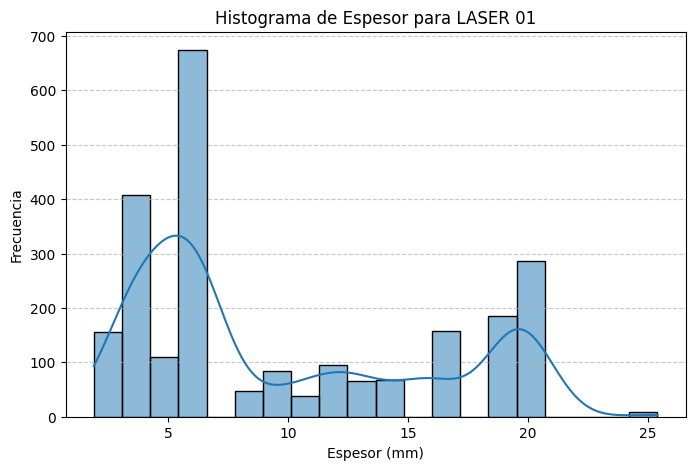

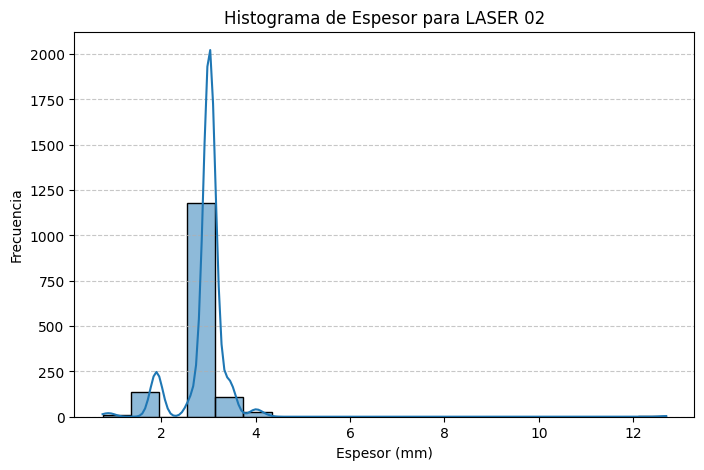

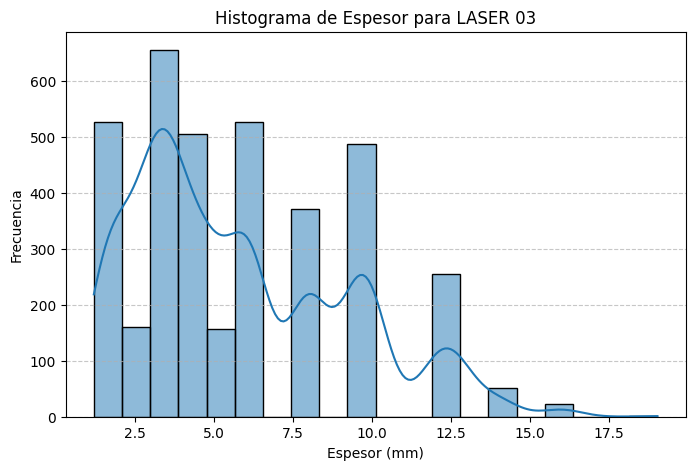

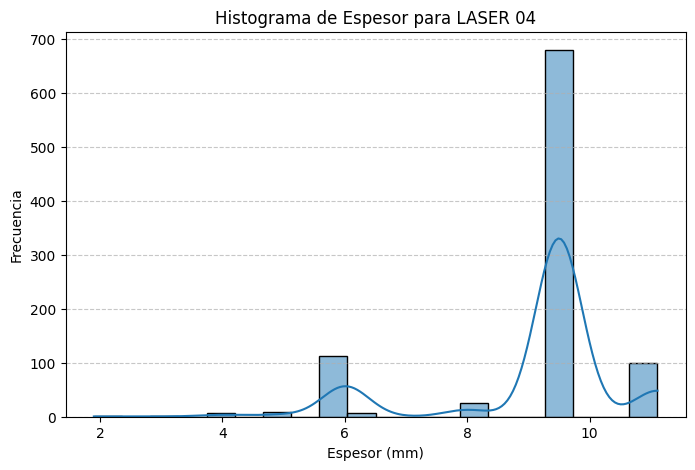

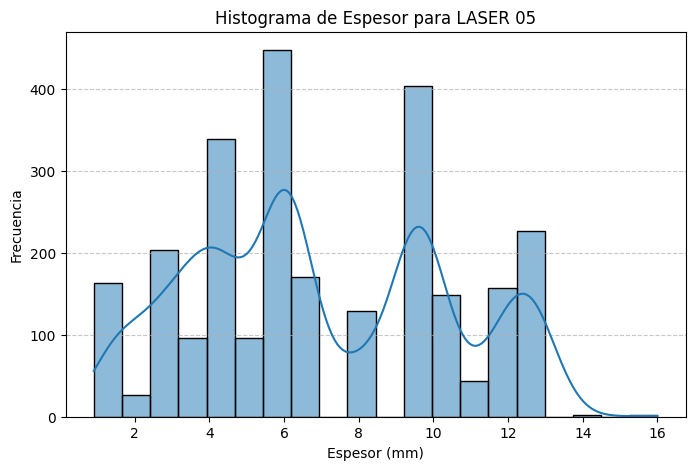

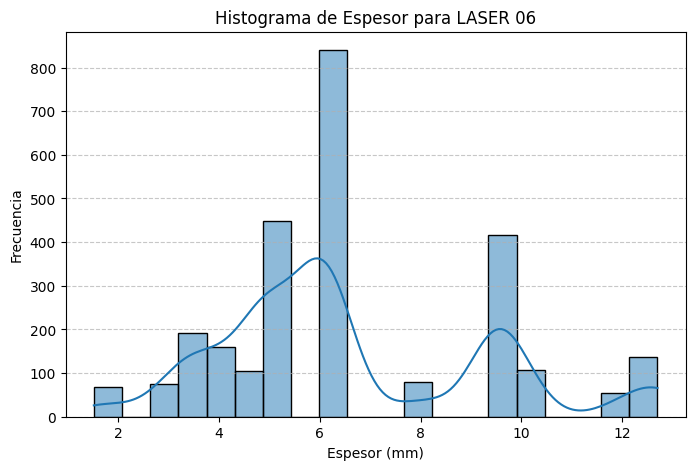

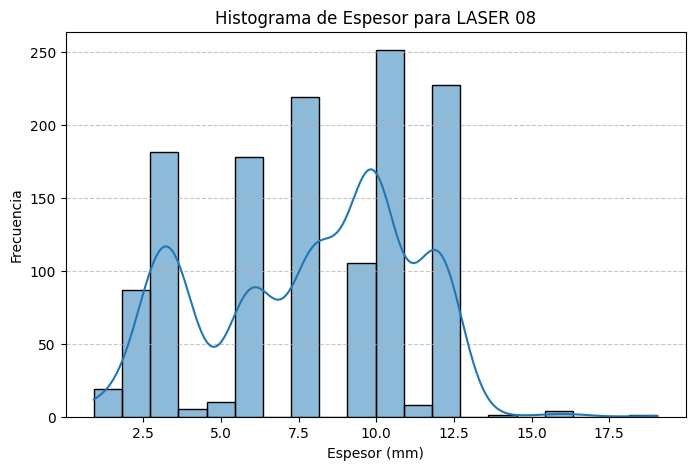

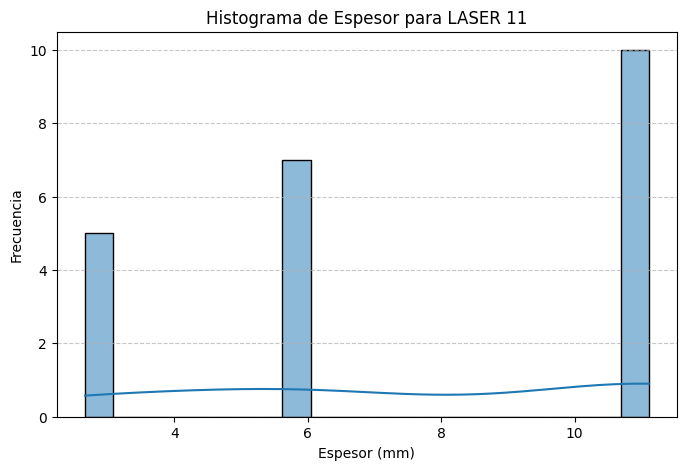

In [ ]:
unique_machines = df_final_2['Maquina'].unique()

for machine in unique_machines:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_final_2[df_final_2['Maquina'] == machine]['Espesor'].dropna(), kde=True, bins=20)
    plt.title(f'Histograma de Espesor para {machine}')
    plt.xlabel('Espesor (mm)')
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()